In [2]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
from peft import LoraConfig, get_peft_model, PeftModel
import torch


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_id = "yoakiyama/MSA-Pairformer"


from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA

msa_pairformer = MSAPairformer.from_pretrained(device=device)


Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 190650.18it/s]


In [3]:
print(msa_pairformer.device)
print(sum(p.numel() for p in msa_pairformer.parameters()) / 1e6, "M parameters")


cuda:0
111.365468 M parameters


In [4]:
# [진단용 셀]
# LoRA 적용 전에 이 셀을 먼저 실행해 보세요.

# 모델의 모듈 중 하나를 직접 출력해봅니다.
print(msa_pairformer.core_stack.layers[0][0].msa_to_values_and_gates[1])

LinearNoBias(in_features=464, out_features=512, bias=False)


In [5]:
# for name, module in msa_pairformer.named_modules():
#     if "to_out" in name:
#         print(name, type(module))


In [6]:
import torch.nn as nn
from peft import LoraConfig, get_peft_model

# 1️⃣ 모든 모듈 이름 출력해서 dropout 있는 애 걸러내기
dropout_names = [name for name, m in msa_pairformer.named_modules() if isinstance(m, nn.Dropout)]
dropout_names_set = set(dropout_names)

# 2️⃣ LoRA 타깃 후보
base_target_modules = [
    "msa_to_values_and_gates.1",
    "pairwise_repr_to_attn.1",
    "to_out.1",
    "lm_head.dense",
]

# 3️⃣ Dropout 이름이 겹치는 경우 자동 제외
safe_targets = []
for t in base_target_modules:
    if not any(t in d for d in dropout_names_set):
        safe_targets.append(t)

print(f" 최종 LoRA 타깃 모듈: {safe_targets}")

# 4️⃣ LoRA 설정 및 적용
lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=safe_targets,
    lora_dropout=0.1,
    bias="none",
)

lora_model = get_peft_model(msa_pairformer, lora_config)
lora_model.print_trainable_parameters()


 최종 LoRA 타깃 모듈: ['msa_to_values_and_gates.1', 'pairwise_repr_to_attn.1', 'lm_head.dense']
trainable params: 1,914,368 || all params: 113,279,836 || trainable%: 1.6899


In [7]:
from peft.tuners.lora import LoraLayer
import torch.nn as nn

def print_lora_injected_layers(model):
    print("\n=== LoRA Injected Layers ===\n")
    
    for name, module in model.named_modules():
        if isinstance(module, LoraLayer):
            print(f"[LoRA Layer] {name}")
            print(module)
            print("-" * 50)


print_lora_injected_layers(lora_model)


=== LoRA Injected Layers ===

[LoRA Layer] base_model.model.core_stack.layers.0.0.msa_to_values_and_gates.1
lora.Linear(
  (base_layer): LinearNoBias(in_features=464, out_features=512, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=464, out_features=64, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=64, out_features=512, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)
--------------------------------------------------
[LoRA Layer] base_model.model.core_stack.layers.0.0.pairwise_repr_to_attn.1
lora.Linear(
  (base_layer): LinearNoBias(in_features=256, out_features=8, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=256, out_features=64, bias=False)
  )
  (lora_B): ModuleDict(


In [8]:
# import torch
# import torch.nn.functional as F
# from torch.optim import Adam
# from MSA_Pairformer.dataset import MSA, msa_mlm, aa2tok_d
# from torch.utils.checkpoint import checkpoint

# # 🔹 1. 디바이스 설정
# device = next(lora_model.parameters()).device

# # # 🔹 2. 모델을 bf16으로 변환
# lora_model = lora_model.to(torch.bfloat16)
# lora_model.train()

# # 🔹 3. MSA 데이터 불러오기
# msa_path = "X5L4P3.a3m"
# msa_data = MSA(msa_path, diverse_select_method="none")
# msa_t = msa_data.diverse_tokenized_msa.unsqueeze(0).to(device)

# # 🔹 4. 마스킹 (mutate_pssm=False)
# masked_msa, mlm_indices = msa_mlm(
#     msa_t.cpu(),
#     mask_prob=0.15,
#     mutate_pssm=False
# )
# masked_msa = masked_msa.to(device)

# # 🔹 5. one-hot 인코딩 (bf16)
# msa_onehot = torch.nn.functional.one_hot(masked_msa, num_classes=28).to(torch.bfloat16).to(device)

# # 🔹 6. forward (autocast로 bf16 연산)
# with torch.cuda.amp.autocast(dtype=torch.bfloat16):
#     output = lora_model(msa=msa_onehot)
#     logits = output["logits"]  # (B, 1, L, vocab)

#     # query-only masking
#     mask = (masked_msa[:, 0, :] == aa2tok_d["<mask>"])  # (B, L)
#     labels = msa_t[:, 0, :]  # (B, L)

#     masked_logits = logits[:, 0, :, :][mask]
#     masked_labels = labels[mask]

#     # 🔹 7. CrossEntropy는 fp32로 계산 (정확도 유지용)
#     loss = F.cross_entropy(masked_logits.float(), masked_labels.long())

# print(f"✅ Loss computed successfully (bf16): {loss.item():.4f} | masked tokens: {mask.sum().item()}")


In [9]:
from glob import glob
import random
from MSA_Pairformer.dataset import MSADataset, CollateAFBatch

# -----------------------------
# 0️⃣ Config
# -----------------------------
msa_root = "/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD"
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

max_seq_len = 128
max_depth = 32

# -----------------------------
# [추가] 랜덤 시드 고정 (이 코드가 꼭 필요합니다!)
# -----------------------------
SEED = 42  # 원하는 숫자로 설정 (보통 42를 많이 씀)
random.seed(SEED)
# 만약 numpy나 torch도 쓴다면 같이 고정하는 게 좋습니다.
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# -----------------------------
# 1️⃣ 모든 .a3m 파일 수집
# -----------------------------
all_files = glob(f"{msa_root}/**/*.a3m", recursive=True)
# glob 결과는 운영체제마다 순서가 다를 수 있으므로, 한 번 정렬 후 섞는 게 가장 안전합니다.
all_files.sort() 

print(f"📁 Found total MSA files: {len(all_files)}")

# 랜덤 셔플 (위에서 seed를 고정했으므로 항상 똑같이 섞임)
random.shuffle(all_files)

# -----------------------------
# 2️⃣ Split
# -----------------------------
N = len(all_files)
train_files = all_files[:int(N * train_ratio)]
val_files   = all_files[int(N * train_ratio):int(N * (train_ratio + val_ratio))]
test_files  = all_files[int(N * (train_ratio + val_ratio)):]

print(f"✔ Train: {len(train_files)}")
print(f"✔ Val:   {len(val_files)}")
print(f"✔ Test:  {len(test_files)}")

📁 Found total MSA files: 351242
✔ Train: 280993
✔ Val:   35124
✔ Test:  35125


In [10]:
from torch.utils.data import DataLoader
import torch

# Dataset
train_dataset = MSADataset(
    msa_paths=train_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

val_dataset = MSADataset(
    msa_paths=val_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

test_dataset = MSADataset(
    msa_paths=test_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

# Collate
train_collate = CollateAFBatch(
    max_seq_length=max_seq_len,
    max_seq_depth=max_depth,
    min_seq_depth=4,
    mask_prob=0,
    mutate_pssm=False,
    query_only=True
)

val_collate = CollateAFBatch(
    max_seq_length=max_seq_len,
    max_seq_depth=max_depth,
    min_seq_depth=4,
    mask_prob=0,
    mutate_pssm=False,
    query_only=True
)

# Dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    collate_fn=train_collate,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    collate_fn=val_collate,
    pin_memory=True
)


In [11]:
from MSA_Pairformer.dataset import MSA

msa = MSA("/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD/A0A513PZY6.a3m")
print(len(msa.seq_a))

497


In [12]:
# -----------------------------
# 1️⃣ Dataloader Sanity Check
# -----------------------------
from MSA_Pairformer.dataset import prepare_inputs_bf16
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA, aa2tok_d, prepare_msa_masks
batch = next(iter(train_loader))

print("✔ Batch loaded!")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k:20s} | shape = {tuple(v.shape)} | dtype = {v.dtype}")
    else:
        print(f"{k:20s} | {v}")

# Prepare inputs (bf16)
msa_repr, mask, msa_mask, full_mask, pairwise_mask, molecule_feats = prepare_inputs_bf16(batch, device)

print("\n✔ Prepared inputs:")
print("msa_repr:", msa_repr.shape)
print("mask:", mask.shape)

# forward
with torch.cuda.amp.autocast(dtype=torch.bfloat16):
    out = lora_model(
        msa=msa_repr,
        mask=mask,
        msa_mask=msa_mask,
        full_mask=full_mask,
        pairwise_mask=pairwise_mask,
        # molecule_feats=molecule_feats,
        return_contacts=False,
        query_only=True
    )

print("\n✔ Forward OK")
print("logits:", out["logits"].shape)


✔ Batch loaded!
msas                 | shape = (1, 32, 128) | dtype = torch.int64
msas_onehot          | shape = (1, 32, 128, 28) | dtype = torch.int64
masked_idx           | None
unmasked_msas_onehot | shape = (1, 32, 128, 28) | dtype = torch.int64
molecule_feats       | shape = (1, 128, 5) | dtype = torch.float32
file_path            | ['/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD/A0A5J6VJA4.a3m']
seq_indices          | [[0, 2, 3, 5, 6, 7, 8, 9, 11, 13, 15, 19, 24, 28, 30, 32, 131, 142, 149]]
msa_depths           | shape = (1,) | dtype = torch.int64
mask                 | shape = (1, 128) | dtype = torch.bool
msa_mask             | shape = (1, 32) | dtype = torch.bool
full_mask            | shape = (1, 32, 128) | dtype = torch.bool
pairwise_mask        | shape = (1, 128, 128) | dtype = torch.bool

✔ Prepared inputs:
msa_repr: torch.Size([1, 32, 128, 28])
mask: torch.Size([1, 128])


/tmp/ipykernel_2058157/1006931040.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16):



✔ Forward OK
logits: torch.Size([1, 1, 128, 26])


In [13]:
# -----------------------------
# 2️⃣ Optimizer & Scheduler
# -----------------------------
from torch.optim import AdamW

# Cell 13 대체용 코드

from transformers import get_cosine_schedule_with_warmup

# 1. 학습률을 낮춥니다 (1e-4 -> 2e-5)
lr = 5e-4
weight_decay = 0.01 # 일반화 성능을 위해 약간의 weight decay 추가

optimizer = torch.optim.AdamW(lora_model.parameters(), lr=lr, weight_decay=weight_decay)

# 2. Warmup 추가 (초반 100 step 동안은 학습률을 천천히 올림 -> 안정성 확보)
# 전체 step 수는 데이터 양에 따라 다르지만, 여기서는 임의로 5000으로 잡습니다.
max_train_steps = 5000
num_warmup_steps = 500

scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup_steps, 
    num_training_steps=max_train_steps
)

print(f"Optimizer & Scheduler Ready (LR: {lr}, Warmup: {num_warmup_steps})")

Optimizer & Scheduler Ready (LR: 0.0005, Warmup: 500)


🛑 단일 배치 오버피팅 테스트 시작...
Iter 10: Loss 0.2702
Iter 20: Loss 0.0650
Iter 30: Loss 0.1102
Iter 40: Loss 0.1718
Iter 50: Loss 0.0129
Iter 60: Loss 0.0020
Iter 70: Loss 0.1645
Iter 80: Loss 0.0338
Iter 90: Loss 0.0084
Iter 100: Loss 0.0040


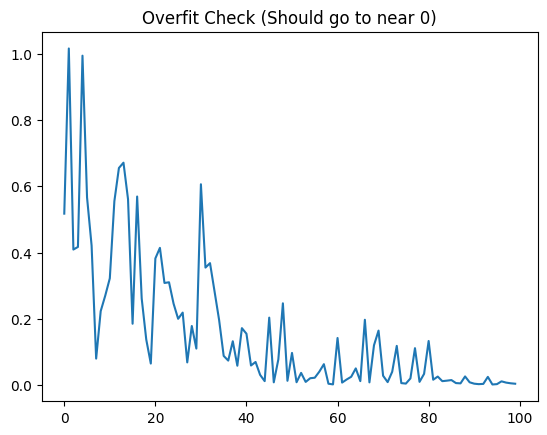

In [14]:
# [디버깅용] 단일 배치 오버피팅 테스트
# 전체 데이터셋 말고, 딱 하나의 배지만 꺼내서 모델이 이걸 외울 수 있는지 봅니다.
import torch
import torch.nn.functional as F
from MSA_Pairformer.dataset import aa2tok_d  # mask 토큰 인덱스 가져오기
# Cell 38 대체용 코드 (Gradient Clipping 추가 & Accumulation 16으로 증가)

ACCUMULATION_STEPS = 16  # 8 -> 16으로 증가 (더 안정적인 학습)
MASK_TOKEN_IDX = aa2tok_d.get("<mask>", 23)

print("🛑 단일 배치 오버피팅 테스트 시작...")

# 1. 데이터 하나 꺼내기
debug_batch = next(iter(train_loader))

# 2. 모델 및 옵티마이저 설정 (학습률을 아주 높게 잡음)
lora_model.train()
debug_optimizer = torch.optim.AdamW(lora_model.parameters(), lr=1e-3) # 강력한 LR

losses = []

# 3. 100번 반복 학습 (같은 데이터로)
for i in range(100):
    # ---- train_step 로직 복사 ----
    msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(debug_batch, device)
    labels = debug_batch["msas"][:, 0, :].to(device).clone()

    # 마스킹 (매번 다르게 하지 말고 고정된 마스크 사용 권장, 여기선 간단히 매번 생성)
    valid_token = (labels >= 0) & (labels < 26)
    rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
    
    # 마스크가 없으면 강제 할당
    if rand_mask.sum() == 0:
        rand_mask[:, 0] = True
        
    masked_positions = rand_mask

    # 입력 마스킹 처리
    msa_repr[:, 0, :, :][masked_positions] = 0.0
    msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

    with torch.amp.autocast("cuda", dtype=torch.bfloat16):
        out = lora_model(
            msa=msa_repr,
            mask=mask,
            msa_mask=msa_mask,
            full_mask=full_mask,
            pairwise_mask=pairwise_mask,
            return_contacts=False,
            query_only=True
        )
        
        logits = out["logits"][:, 0, :, :]
        pred = logits[masked_positions]
        true = labels[masked_positions]
        
        loss = F.cross_entropy(pred.float(), true.long())

    # Backward
    debug_optimizer.zero_grad()
    loss.backward()
    debug_optimizer.step()
    
    losses.append(loss.item())
    
    if (i+1) % 10 == 0:
        print(f"Iter {i+1}: Loss {loss.item():.4f}")

# 결과 시각화
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Overfit Check (Should go to near 0)")
plt.show()

In [16]:
# [수정된 train_step 및 val_step]
# 이 셀을 기존 함수 정의 대신 실행하세요.

import torch
import torch.nn.functional as F
from MSA_Pairformer.dataset import aa2tok_d  # mask 토큰 인덱스 가져오기
# Cell 38 대체용 코드 (Gradient Clipping 추가 & Accumulation 16으로 증가)

ACCUMULATION_STEPS = 16  # 8 -> 16으로 증가 (더 안정적인 학습)
MASK_TOKEN_IDX = aa2tok_d.get("<mask>", 23)

def train_step(batch, step_idx):
    lora_model.train()

    # 1) Inputs
    msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(batch, device)
    labels = batch["msas"][:, 0, :].to(device).clone()

    # 2) Masking Logic
    valid_token = (labels >= 0) & (labels < 26) 
    rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
    
    if rand_mask.sum() == 0:
        valid_indices = torch.where(valid_token)[1]
        if len(valid_indices) > 0:
            rand_idx = valid_indices[torch.randint(0, len(valid_indices), (1,))]
            rand_mask[:, rand_idx] = True
            
    masked_positions = rand_mask

    # 3) Apply Mask to Input (Leakage 방지)
    msa_repr[:, 0, :, :][masked_positions] = 0.0
    msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

    # 4) Forward
    with torch.amp.autocast("cuda", dtype=torch.bfloat16):
        out = lora_model(
            msa=msa_repr,
            mask=mask,
            msa_mask=msa_mask,
            full_mask=full_mask,
            pairwise_mask=pairwise_mask,
            return_contacts=False,
            query_only=True
        )

        logits = out["logits"][:, 0, :, :]
        pred = logits[masked_positions]
        true = labels[masked_positions]

        valid_label_mask = (true >= 0) & (true < logits.size(-1))
        pred = pred[valid_label_mask]
        true = true[valid_label_mask]

        if true.numel() == 0:
            return 0.0

        loss = F.cross_entropy(pred.float(), true.long())
        loss = loss / ACCUMULATION_STEPS

    # 5) Backward
    loss.backward()

    # 6) Optimizer Step with Gradient Clipping (핵심 추가 사항)
    if (step_idx + 1) % ACCUMULATION_STEPS == 0:
        # 그라디언트가 너무 크면(1.0 초과) 잘라냅니다. 튀는 현상 방지.
        torch.nn.utils.clip_grad_norm_(lora_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return loss.item() * ACCUMULATION_STEPS
def val_step(batch):
    lora_model.eval()

    with torch.no_grad():
        msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(batch, device)
        labels = batch["msas"][:, 0, :].to(device)

        # Validation에서도 동일하게 마스킹을 해서 '복원 능력'을 평가해야 함
        valid_token = (labels >= 0) & (labels < 26)
        rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
        masked_positions = rand_mask

        # [검증용] 입력 마스킹 적용
        msa_repr[:, 0, :, :][masked_positions] = 0.0
        msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            out = lora_model(
                msa=msa_repr,
                mask=mask,
                msa_mask=msa_mask,
                full_mask=full_mask,
                pairwise_mask=pairwise_mask,
                return_contacts=False,
                query_only=True
            )

        logits = out["logits"][:, 0, :, :]
        
        pred = logits[masked_positions]
        true = labels[masked_positions]
        
        valid_label_mask = (true >= 0) & (true < logits.size(-1))
        pred = pred[valid_label_mask]
        true = true[valid_label_mask]

        if true.numel() == 0:
            return None

        loss = F.cross_entropy(pred.float(), true.long())

    return loss.item()

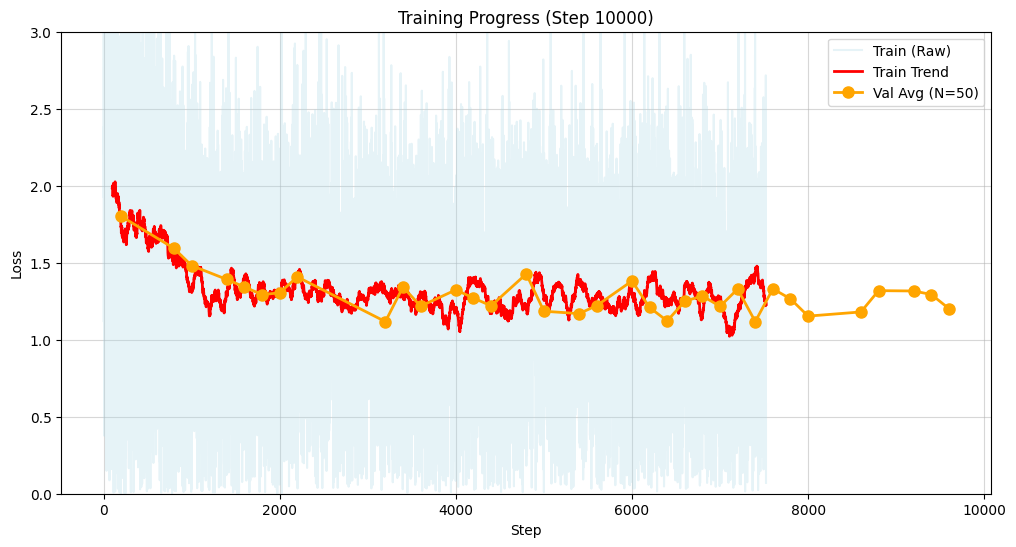

Training Finished.


In [18]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm
import numpy as np

# -----------------------------------------------------------
# [수정됨] 오류 없는 라이브 플롯 함수
# -----------------------------------------------------------
def live_plot(train_loss_list, val_step_list, val_loss_list, current_step):
    clear_output(wait=True)
    plt.figure(figsize=(12, 6))
    
    # Train Loss (흐리게)
    plt.plot(train_loss_list, label='Train (Raw)', color='lightblue', alpha=0.3)
    
    # Train Trend (진하게)
    if len(train_loss_list) > 10:
        # 윈도우 크기를 고정하지 않고 데이터 상황에 맞게 처리
        window_size = 100
        ma = moving_average(train_loss_list, window_size)
        
        # [핵심 수정] X축 범위를 데이터(ma) 길이에 맞춰서 자동으로 생성
        # 데이터가 적어서 원본이 반환되든, 많아서 평균이 반환되든 항상 길이가 맞음
        x_range = range(len(train_loss_list) - len(ma), len(train_loss_list))
        
        plt.plot(x_range, ma, label='Train Trend', color='red', linewidth=2)

    # Val Loss (주황색 점 & 선)
    if len(val_loss_list) > 0:
        plt.plot(val_step_list, val_loss_list, label=f'Val Avg (N={VAL_BATCHES})', 
                 color='orange', marker='o', linewidth=2, markersize=8)

    plt.title(f'Training Progress (Step {current_step})')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.ylim(0, 3.0)
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.show()

# -----------------------------------------------------------
# 학습 루프 재시작
# -----------------------------------------------------------
# (주의: 이전 셀에서 train_losses 등이 초기화되지 않도록 주의하세요.
#  만약 처음부터 다시 하려면 위쪽 변수 초기화 코드도 실행해야 합니다.
#  여기서는 이어서 한다고 가정하고 루프만 다시 돌립니다.)

# 혹시 멈춰서 pbar가 닫혔을 수 있으니 다시 생성
# 이미 진행된 step부터 시작하도록 range 조정
start_step = len(train_losses) # 대략적으로 현재 진행된 곳부터
if start_step >= MAX_STEPS:
    print("이미 학습이 완료되었습니다.")
else:
    print(f"Resuming training from step {start_step}...")
    
    # Iterator를 다시 해당 위치로 이동 (skip)
    train_iter = iter(train_loader)
    for _ in range(start_step):
        next(train_iter, None)
        
    pbar = tqdm(enumerate(train_iter, start=start_step), total=MAX_STEPS, initial=start_step)
    
    for step, batch in pbar:
        if step >= MAX_STEPS: break
        if batch is None: continue

        # 1. TRAIN
        loss = train_step(batch, step)
        if loss != 0.0:
            train_losses.append(loss)

        # 2. VALIDATE (N개 배치 평균)
        avg_val_loss = None
        
        if step % VAL_INTERVAL == 0 and step > 0:
            temp_val_losses = []
            lora_model.eval()
            
            for _ in range(VAL_BATCHES):
                try:
                    v_batch = next(val_iter)
                except StopIteration:
                    val_iter = iter(val_loader)
                    v_batch = next(val_iter)
                
                if v_batch is not None:
                    v_loss = val_step(v_batch)
                    if v_loss is not None:
                        temp_val_losses.append(v_loss)
            
            lora_model.train()
            
            if len(temp_val_losses) > 0:
                avg_val_loss = sum(temp_val_losses) / len(temp_val_losses)
                val_losses.append(avg_val_loss)
                val_steps.append(step)

        # 3. Plot & Log (수정된 함수 사용)
        if step % 50 == 0:
            live_plot(train_losses, val_steps, val_losses, step)

        # 상태바
        log_dict = {"Tr_Loss": f"{loss:.4f}"}
        if avg_val_loss is not None:
            log_dict["Val_Avg"] = f"{avg_val_loss:.4f}"
        elif len(val_losses) > 0:
            log_dict["Val_Avg"] = f"{val_losses[-1]:.4f}"
            
        pbar.set_postfix(log_dict)

    pbar.close()
    live_plot(train_losses, val_steps, val_losses, step)
    print("Training Finished.")

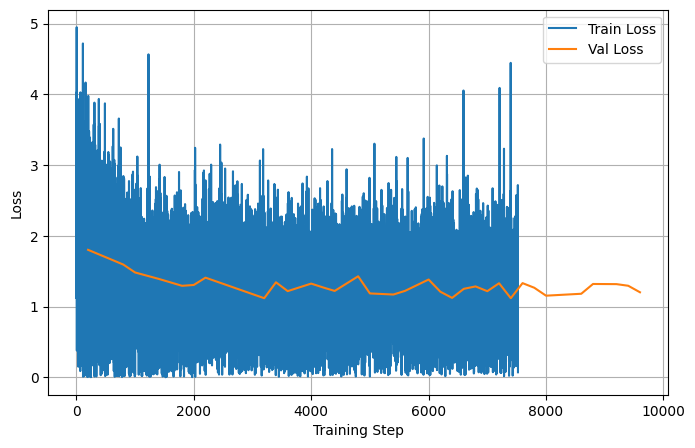

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

# Train
plt.plot(range(len(train_losses)), train_losses, label="Train Loss")

# Validation (step 기반)
plt.plot(val_steps, val_losses, label="Val Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

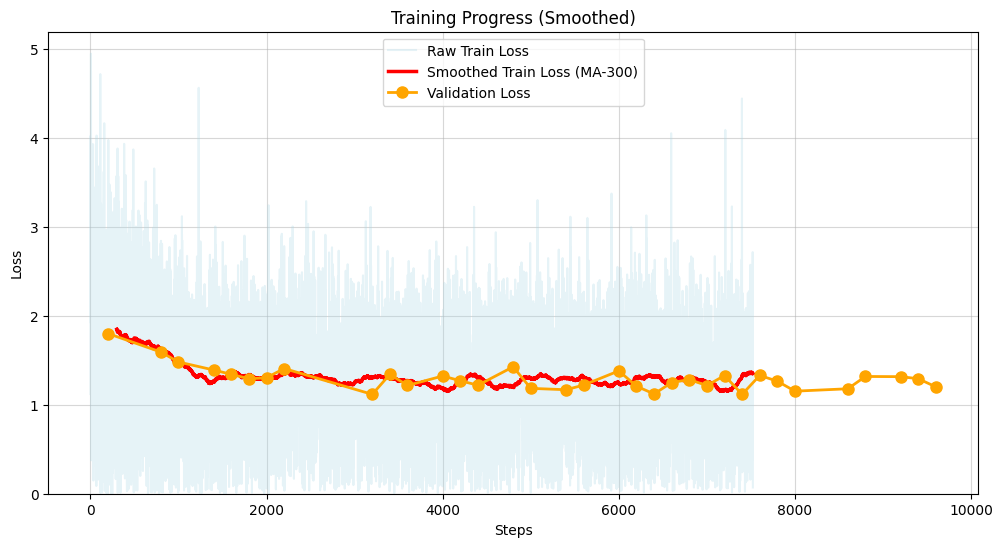

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. 데이터 스무딩 함수 (윈도우 크기 대폭 증가)
# ---------------------------------------------------------
def smooth_curve(points, window_size=300): # 50 -> 300으로 변경 (더 부드럽게)
    if len(points) < window_size:
        return points
    # 컨볼루션을 이용한 이동 평균 계산
    box = np.ones(window_size) / window_size
    return np.convolve(points, box, mode='valid')

# 스무딩 적용
smooth_train_losses = smooth_curve(train_losses, window_size=300)

# ---------------------------------------------------------
# 2. 그래프 그리기
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# (1) 원본 Train Loss (너무 지저분하면 투명도를 낮추거나 주석 처리하세요)
plt.plot(train_losses, label='Raw Train Loss', color='lightblue', alpha=0.3)

# (2) 스무딩된 Train Loss (진한 빨간색)
# x축 보정을 위해 앞부분(window_size만큼)을 띄우고 그립니다
plt.plot(
    range(300-1, len(train_losses)), 
    smooth_train_losses, 
    label='Smoothed Train Loss (MA-300)', 
    color='red', 
    linewidth=2.5
)

# (3) Validation Loss (점)
if len(val_steps) > 0:
    plt.plot(val_steps, val_losses, label='Validation Loss', color='orange', marker='o', linewidth=2, markersize=8)

plt.title('Training Progress (Smoothed)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.5)
plt.ylim(bottom=0) # 0부터 시작하도록 고정 (선택사항)
plt.show()

In [21]:
import os

# 저장할 폴더 이름 설정
save_directory = "./fine_tuned_msa_lora"

# 폴더가 없으면 생성
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

# ---------------------------------------------------------
# 모델 저장 (LoRA 어댑터만 저장됨)
# ---------------------------------------------------------
print(f"Saving LoRA adapters to {save_directory}...")
lora_model.save_pretrained(save_directory)

print("✅ Model saved successfully!")
print(f"- Adapter config: {os.path.join(save_directory, 'adapter_config.json')}")
print(f"- Adapter weights: {os.path.join(save_directory, 'adapter_model.bin')}")

Saving LoRA adapters to ./fine_tuned_msa_lora...
✅ Model saved successfully!
- Adapter config: ./fine_tuned_msa_lora/adapter_config.json
- Adapter weights: ./fine_tuned_msa_lora/adapter_model.bin


In [22]:
# (참고용 코드) 나중에 불러올 때
from peft import PeftModel, PeftConfig
from MSA_Pairformer.model import MSAPairformer

# 1. 원본 베이스 모델 로드
base_model = MSAPairformer.from_pretrained(device=device)

# 2. 저장해둔 LoRA 어댑터 결합
model_to_load = PeftModel.from_pretrained(base_model, "./fine_tuned_msa_lora")

# 3. 평가 모드 전환
model_to_load.eval()
model_to_load.to(device)
print("LoRA model loaded!")

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 59918.63it/s]


LoRA model loaded!


In [24]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from peft import PeftModel
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import aa2tok_d, prepare_inputs_bf16

# ----------------------------------------------------------------
# 1. 평가 함수 정의 (샘플 제한 기능 추가)
# ----------------------------------------------------------------
MASK_TOKEN_IDX = aa2tok_d.get("<mask>", 23)

def evaluate_loss_limited(model, dataloader, device, max_samples=1000, desc="Evaluating"):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    # 진행 바 설정 (최대 max_samples 만큼)
    pbar = tqdm(dataloader, total=max_samples, desc=desc)
    
    with torch.no_grad():
        for i, batch in enumerate(pbar):
            # 제한된 샘플 수에 도달하면 중단
            if i >= max_samples:
                break
                
            if batch is None: continue

            # 1) 입력 준비
            msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(batch, device)
            labels = batch["msas"][:, 0, :].to(device).clone()

            # 2) 마스킹 (Train과 동일하게 15%)
            valid_token = (labels >= 0) & (labels < 26)
            rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
            
            # 마스크 없으면 강제 할당 (예외 처리)
            if rand_mask.sum() == 0:
                valid_indices = torch.where(valid_token)[1]
                if len(valid_indices) > 0:
                    rand_idx = valid_indices[torch.randint(0, len(valid_indices), (1,))]
                    rand_mask[:, rand_idx] = True
            
            masked_positions = rand_mask

            # 3) 입력 데이터 구멍 뚫기
            msa_repr[:, 0, :, :][masked_positions] = 0.0
            msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

            # 4) 모델 Forward
            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                out = model(
                    msa=msa_repr,
                    mask=mask,
                    msa_mask=msa_mask,
                    full_mask=full_mask,
                    pairwise_mask=pairwise_mask,
                    return_contacts=False,
                    query_only=True
                )
                
                logits = out["logits"][:, 0, :, :]
                pred = logits[masked_positions]
                true = labels[masked_positions]
                
                valid_label_mask = (true >= 0) & (true < logits.size(-1))
                pred = pred[valid_label_mask]
                true = true[valid_label_mask]

                if true.numel() > 0:
                    loss = F.cross_entropy(pred.float(), true.long())
                    total_loss += loss.item()
                    num_batches += 1
            
            # 실시간 평균 Loss 표시
            current_avg = total_loss / num_batches if num_batches > 0 else 0
            pbar.set_postfix({"Avg Loss": f"{current_avg:.4f}"})

    return total_loss / num_batches if num_batches > 0 else 0.0

# ----------------------------------------------------------------
# 2. 실행 및 비교
# ----------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LIMIT = 2000  # 평가할 샘플 수

# (1) Test DataLoader (셔플 True 권장: 랜덤하게 1000개 뽑기 위해)
# 하지만 두 모델 간 공정한 비교를 위해 고정된 순서(Shuffle=False)로 앞에서 1000개만 씁니다.
test_loader = DataLoader(
    test_dataset, 
    batch_size=1, 
    shuffle=False, 
    num_workers=2, 
    collate_fn=val_collate
)

print(f"📊 Fast Comparison (First {LIMIT} samples)...")

# --- [A] Base Model ---
print("\n1. Base Model Evaluating...")
base_model = MSAPairformer.from_pretrained(device=device)
base_model.to(torch.bfloat16)
base_model.eval()

loss_base = evaluate_loss_limited(base_model, test_loader, device, max_samples=LIMIT, desc="Base Model")

del base_model
torch.cuda.empty_cache()

# --- [B] Fine-tuned Model ---
print("\n2. Fine-tuned Model Evaluating...")
base_model_ft = MSAPairformer.from_pretrained(device=device)
ft_model_path = "./fine_tuned_msa_lora"
ft_model = PeftModel.from_pretrained(base_model_ft, ft_model_path)
ft_model.to(torch.bfloat16)
ft_model.eval()

loss_ft = evaluate_loss_limited(ft_model, test_loader, device, max_samples=LIMIT, desc="FT Model")

# ----------------------------------------------------------------
# 3. 최종 결과
# ----------------------------------------------------------------
print("\n" + "="*45)
print(f"📢 Result on {LIMIT} Test Samples")
print(f"="*45)
print(f"📉 Base Model Loss : {loss_base:.4f}")
print(f"📉 Finetuned Loss  : {loss_ft:.4f}")
print(f"-"*45)
improvement = loss_base - loss_ft
print(f"🚀 Improvement     : {improvement:+.4f} (Lower is better)")
print(f"="*45)

📊 Fast Comparison (First 2000 samples)...

1. Base Model Evaluating...


Base Model:   7%|▋         | 147/2000 [00:07<01:18, 23.74it/s, Avg Loss=1.3011]/home/mooolab/anaconda3/envs/yoosun/lib/python3.11/site-packages/Bio/SeqIO/FastaIO.py:203: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. Thie format allows for comments before the first sequence; lines st


2. Fine-tuned Model Evaluating...


FT Model:   7%|▋         | 145/2000 [00:06<01:27, 21.31it/s, Avg Loss=1.2396]/home/mooolab/anaconda3/envs/yoosun/lib/python3.11/site-packages/Bio/SeqIO/FastaIO.py:203: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. Thie format allows for comments before the first sequence; lines star


📢 Result on 2000 Test Samples
📉 Base Model Loss : 1.3041
📉 Finetuned Loss  : 1.2718
---------------------------------------------
🚀 Improvement     : +0.0323 (Lower is better)


In [1]:
#what is the next step-> DMS score framework